# Lab 2 — Messy Data & Leakage-Safe Features
**DSA 8401 Applied Machine Learning · Chapter 2**

Works the mobile-money dump `mobile_money_statements.csv`:
1. **Audit** — missingness / duplicates / validity, MCAR/MAR/MNAR classification
2. **Clean & aggregate** — parse amounts/dates, resolve `customer_id`, build RFM features
3. **Hunt the leak** — correlation screen for planted leaks
4. **Pipeline** — `ColumnTransformer` + `Pipeline`, group-aware CV, ROC-AUC with/without leaks
5. **Extension** — fuller audit, 17-feature dictionary, per-leak quantification, persisted pipeline

**Part 2 (below, Sections 6+)** extends this into **Assignment 2 — The Cost of Being Wrong**: purged/blocked time-series CV, an ensemble model ladder, cost-based thresholding, imbalance handling, Optuna tuning, calibration, and SHAP/fairness.

In [1]:
import re, warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")



In [2]:
# The scoring timestamp: every feature is computed over data strictly BEFORE this
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")



In [3]:
import os

# Look for the CSV next to the notebook first, fall back to the original lab path
candidates = ["mobile_money_statements.csv",
              r"C:\Users\Lbundi\Desktop\Strathmore Lectures\AML YR 26\Data\mobile_money_statements.csv"]
data_path = next((p for p in candidates if os.path.exists(p)), candidates[0])

raw = pd.read_csv(data_path)
print("raw shape:", raw.shape)
raw.head(3)

raw shape: (183600, 18)


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,gps_lon,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,NaN,AG1014,DV978723,CP6324,8123.0,0.061,settled,0
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,34.70915,AG1084,DV616667,CP2831,6322.0,0.000,settled,0
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,33.67018,AG1091,DV637734,CP167,15237.0,0.912,reversed,1


## 1. Audit
Missingness fraction per column, whether it's informative, duplicates, and validity violations.

In [4]:
# 1a. Missingness fraction per column (Listing 2.1, step 1) ---


miss = raw.isna().mean().sort_values(ascending=False)

print("Missing fraction per column:")

print(miss[miss > 0].round(4).to_string())

Missing fraction per column:
gps_lon      0.3621
gps_lat      0.3621
agent_id     0.1369
device_id    0.0591


In [5]:
# 1b. Duplicates ---
# Exact row duplicates (client retries / log merges) -> drop_duplicates dispatches them.


print("exact duplicate rows :", int(raw.duplicated().sum()))

print("duplicate txn_id      :", int(raw['txn_id'].duplicated().sum()))


# txn_id repeats exactly on the duplicate rows they are true row copies, not new events.

exact duplicate rows : 3600
duplicate txn_id      : 3600


In [6]:
# 1c. Validity-rule violations ---

# amount is stored as a STRING with thousands separators, a "/-" suffix, and three
# different debit encodings; it will not cast to a number as-is.

print("amount dtype:", raw['amount'].dtype)

print("amount samples:", raw['amount'].dropna().sample(6, random_state=1).tolist())

# txn_time mixes three formats -> a single to_datetime(format=...) cannot parse all rows.
print("txn_time samples:", raw['txn_time'].sample(6, random_state=2).tolist())

amount dtype: str
amount samples: ['71/- Dr', '4,742/- Dr', '1,701/-', '(227/-)', '(165/-)', '(51/-)']
txn_time samples: ['29/06/2026 04:49', '2025-09-09 05:09:38', 'Mar 20, 2026 02:09 PM', 'May 04, 2025 08:43 PM', '2026-03-30 12:00:04', '03/08/2025 21:49']


In [7]:
raw['agent_id'].isna().astype(int)

0         0
1         0
2         0
3         0
4         1
         ..
183595    0
183596    1
183597    0
183598    0
183599    0
Name: agent_id, Length: 183600, dtype: int64

In [8]:
# -1d. Is missingness informative? (the MNAR screen)

# Compare the target rate across the missing indicator for each incomplete column.

for col in ["gps_lat", "agent_id", "device_id"]:

    # Fraud rate when the value is present
    present_rate = raw.loc[raw[col].notna(), "is_fraud"].mean()

    # Fraud rate when the value is missing
    missing_rate = raw.loc[raw[col].isna(), "is_fraud"].mean()

    print(f"\n{col}")
    print(f"  Present : {present_rate:.4f}")
    print(f"  Missing : {missing_rate:.4f}")


gps_lat
  Present : 0.0839
  Missing : 0.0843

agent_id
  Present : 0.0841
  Missing : 0.0839

device_id
  Present : 0.0840
  Missing : 0.0838


In [9]:
# 1e. Can OBSERVED columns explain the missingness? (MAR test) ---
# agent_id: missing fraction by region.


# Percentage of missing agent_id values in each region
print("Missing agent_id by region")
print(
    raw.groupby("region")["agent_id"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

# Percentage of missing gps_lat values in each region
print("\nMissing gps_lat by region")
print(
    raw.groupby("region")["gps_lat"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

# Percentage of missing device_id values in each region
print("\nMissing device_id by region")
print(
    raw.groupby("region")["device_id"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

Missing agent_id by region
region
Arusha           0.452
Dar es Salaam    0.000
Eldoret          0.000
Jinja            0.451
Kampala          0.000
Kigali           0.000
Mombasa          0.000
Mwanza           0.448
Nairobi          0.000
Nakuru           0.000
Name: agent_id, dtype: float64

Missing gps_lat by region
region
Arusha           0.360
Dar es Salaam    0.362
Eldoret          0.357
Jinja            0.365
Kampala          0.365
Kigali           0.367
Mombasa          0.354
Mwanza           0.364
Nairobi          0.360
Nakuru           0.366
Name: gps_lat, dtype: float64

Missing device_id by region
region
Arusha           0.060
Dar es Salaam    0.059
Eldoret          0.058
Jinja            0.056
Kampala          0.061
Kigali           0.061
Mombasa          0.060
Mwanza           0.058
Nairobi          0.059
Nakuru           0.058
Name: device_id, dtype: float64


### Step 1 — MCAR / MAR / MNAR

- **MCAR** — missing completely at random, unrelated to any variable
- **MAR** — missingness explained by an *observed* column
- **MNAR** — missingness depends on the *unobserved value itself*

**Duplicates:** 3,600 exact-copy rows (repeated `txn_id`) — dropped before any split.
**Validity:** `amount` is a string with three debit encodings; `txn_time` mixes three date formats. Both parsed below.

| Column | Missing | Evidence | Class |
|---|---|---|---|
| `agent_id` | ~14% | Missing fraction is ~45% in **Mwanza / Jinja / Arusha** and ~0% everywhere else — missingness is **fully explained by the observed `region`** column (a legacy logger in those regions). | **MAR** |
| `device_id` | ~6% | Missing fraction is flat across region/type and the missing-indicator does **not** move the fraud rate; there is no mechanism tying it to any value. Uniform, uninformative dropout. | **MCAR** |
| `gps_lat` / `gps_lon` | ~36% | Flat across observed columns too (so **not** MAR-explainable), but network/GPS coverage is worse in remote locations, i.e. the probability a coordinate is missing **depends on the coordinate itself**. | **MNAR** |


## 2. Clean and aggregate
Deduplicate, parse amounts/dates, resolve `customer_id`, build customer-level RFM/ratio/cyclical features as-of `SCORING_TS`.

In [10]:
#- 2a. Exact deduplication 
df = raw.drop_duplicates().reset_index(drop=True)
print("after dedup:", df.shape)

after dedup: (180000, 18)


In [11]:
# -2b. Parse the string amount into a signed numeric amount ---

# debit if it starts with '-', is wrapped in (), or is tagged ' Dr'; credit otherwise.

def parse_amount(s):
    
    s = str(s).strip()
    
    neg = s.startswith("(") or s.startswith("-") or "Dr" in s
    
    digits = re.sub(r"[^0-9]", "", s)          # strip commas, '/-', parens, 'Dr', sign
    
    if digits == "":
        return np.nan
    v = float(digits)
    return -v if neg else v



In [12]:
df["amount_signed"]    = df["amount"].map(parse_amount)  
df["amount_abs"]       = df["amount_signed"].abs()



print("amount parse failures:", int(df["amount_signed"].isna().sum()))
df[["amount", "amount_signed"]].head(4)

amount parse failures: 0


,amount,amount_signed
0,"1,329/- Dr",-1329.0
1,289/- Dr,-289.0
2,"1,571/-",1571.0
3,599/- Dr,-599.0


In [13]:
# Convert the transaction time column to text
s = df["txn_time"].astype(str)

# Try parsing the dates using different formats

# Format 1: 2025-01-15 14:30:00
ts = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Format 2: 15/01/2025 14:30
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(
                s[mask],
                format="%d/%m/%Y %H:%M",
                errors="coerce"
            )

# Format 3: Jan 15, 2025 02:30 PM
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(
                    s[mask],
                    format="%b %d, %Y %I:%M %p",
                    errors="coerce"
                )

# Save the parsed dates
df["ts"] = ts

# Check how many dates could not be parsed
print("Number of invalid dates:", df["ts"].isna().sum())

# Check that all transactions happened before the scoring date
print("All transactions before scoring date:",
      (df["ts"] < SCORING_TS).all())

Number of invalid dates: 0
All transactions before scoring date: True


In [14]:
df["reg_id"].nunique()

11722

In [15]:
# - 2d. Entity resolution canonical customer_id 


# The msisdn (SIM) is NOT the identity: multi-SIM customers own several. The KYC
# registration id (reg_id) is the linking key; every SIM a person registers shares it.
# It is lightly messy (case / whitespace), so canonicalise before grouping.


# Create a clean customer ID
df["customer_id"] = (
                df["reg_id"]
                .astype(str)      # Convert to text
                .str.strip()      # Remove spaces
                .str.upper()      # Convert to uppercase
            )

# Count unique values
print("Unique SIM numbers (msisdn):", df["msisdn"].nunique())
print("Unique raw registration IDs:", df["reg_id"].nunique())
print("Unique cleaned customer IDs:", df["customer_id"].nunique())

#   keying on msisdn (or raw reg_id) would badly over-count customers and scatter a
#   person's SIMs across CV folds (leakage cause 5). We group on customer_id instead.

Unique SIM numbers (msisdn): 4825
Unique raw registration IDs: 11722
Unique cleaned customer IDs: 3991


In [16]:
# The scoring timestamp: every feature is computed over data strictly BEFORE this
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")

In [17]:
# Keep only transactions before the scoring date
df = df[df["ts"] < SCORING_TS].copy()

# ----------------------------
# Create time-based features
# ----------------------------

# Extract the hour of the day (0–23)
df["hour"] = df["ts"].dt.hour

# Extract the day of the week (Monday=0, Sunday=6)
df["dow"] = df["ts"].dt.dayofweek

# Extract the day of the month (1–31)
day = df["ts"].dt.day

# ----------------------------
# Create cyclical features
# ----------------------------

# Hour of the day
df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of the week
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

# ----------------------------
# Other useful features
# ----------------------------

# Distance from the nearest payday (1st or 28th of the month)
df["payday_dist"] = np.minimum((day - 1).abs(), (day - 28).abs())

# Reduce the effect of very large transaction amounts
df["log_amt"] = np.log1p(df["amount_abs"])

# Flag whether the GPS location is missing
df["gps_missing"] = df["gps_lat"].isna().astype(int)

In [18]:
# --- 2f. Customer-level RFM / ratio aggregates as-of SCORING_TS (Table 2.2) ---
# All aggregates use only rows with ts < SCORING_TS (enforced above), so no feature


is_debit  = df["amount_signed"] < 0
by        = df.groupby("customer_id")


agg     = pd.DataFrame({
                        "recency_days":   (SCORING_TS - by["ts"].max()).dt.total_seconds() / 86400,    # R
                        "frequency":      by.size(),                                                   # F
                        "monetary_out":   df.assign(o=np.where(is_debit,  df["amount_abs"], 0)).groupby("customer_id")["o"].sum(),  # M
                        "monetary_in":    df.assign(i=np.where(~is_debit, df["amount_abs"], 0)).groupby("customer_id")["i"].sum(),
                        "n_counterparty": by["counterparty"].nunique(),                                                          # stability: distinct counterparties
                        "cashout_ratio":  df.assign(c=(df["txn_type"]=="cashout").astype(int)).groupby("customer_id")["c"].mean(),
                    })


agg["out_in_ratio"] = agg["monetary_out"] / (agg["monetary_in"] + 1.0)  # scale-free ratio
df = df.merge(agg, on="customer_id", how="left")

print("modelling table:", df.shape, "| customers:", df["customer_id"].nunique())

df[["customer_id","recency_days","frequency","monetary_out","monetary_in",
    "n_counterparty","cashout_ratio","out_in_ratio"]].head(3)

modelling table:

 (180000, 38) | customers: 3991


,customer_id,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio
0,NID101089,12.508333,125,158085.0,73259.0,123,0.136000,2.157862
1,NID103658,12.170995,59,60882.0,44395.0,58,0.118644,1.371340
2,NID101584,1.488889,31,33101.0,26404.0,31,0.129032,1.253588


## 3. Hunt the leak
Correlation screen — rank features by |ρ(f, y)| and interrogate the top of the list.

In [19]:
# --- 3a. Correlation screen over numeric candidates 
num_candidates = ["manual_review_score", "amount_abs", "log_amt",
                  "hr_sin", "hr_cos", "dow_sin", "dow_cos", "payday_dist", "gps_missing",
                  "recency_days", "frequency", "monetary_out", "monetary_in",
                  "n_counterparty", "cashout_ratio", "out_in_ratio"]


y = df["is_fraud"].values


corr = pd.Series({c: abs(np.corrcoef(df[c].fillna(df[c].median()), y)[0, 1]) for c in num_candidates}).sort_values(ascending=False)


print("|corr| with is_fraud:")
print(corr.round(3).to_string())

# manual_review_score ~0.98 <-- statistical smoke.

|corr| with is_fraud:
manual_review_score    0.981
hr_cos                 0.071
hr_sin                 0.032
log_amt                0.022
amount_abs             0.016
cashout_ratio          0.010
monetary_out           0.004
frequency              0.003
n_counterparty         0.003
monetary_in            0.003
payday_dist            0.002
out_in_ratio           0.002
dow_sin                0.002
recency_days           0.002
gps_missing            0.000
dow_cos                0.000


In [20]:
# --- 3b. The categorical suspect: settlement_status class separation ---

print("fraud rate by settlement_status:")
print(df.groupby("settlement_status")["is_fraud"].mean().round(3).to_string())

print("\ncounts:")
print(df["settlement_status"].value_counts().to_string())
# 'reversed' -> 100% fraud, 'held' -> ~65%, 'settled'/'pending' -> ~0%: near-perfect split.

fraud rate by settlement_status:
settlement_status
held        0.651
pending     0.000
reversed    1.000
settled     0.004

counts:
settlement_status
settled     154760
reversed      9903
pending       8241
held          7096


## 4. Pipeline
`ColumnTransformer` + `Pipeline`, refit inside every CV fold. `GroupKFold` on `customer_id`. ROC-AUC with and without the leaky columns.

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GroupKFold

NUMERICAL_COLS = ["amount_abs", "log_amt", "hr_sin", "hr_cos", "dow_sin", "dow_cos",
              "payday_dist", "gps_missing", "recency_days", "frequency",
              "monetary_out", "monetary_in", "n_counterparty", "cashout_ratio", "out_in_ratio"]

CATEGORY_COLS = ["txn_type", "region", "segment"]

LEAK_NUM   = ["manual_review_score"]     # <- to be dropped
LEAK_CAT   = ["settlement_status"]       # <- to be dropped

def build_model(num_cols, cat_cols):
    num = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("power",  PowerTransformer(method="yeo-johnson")),  # transform to Gaussian-like for LR
        ("scale",  RobustScaler()),# scaling
    ])
    cat = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
    ])
    prep = ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])
    
    results= Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000))]) # Pipeline with preprocessing and classifier
    
    return results

y       = df["is_fraud"].values
groups  = df["customer_id"].values           # split by resolved customer, never by SIM
cv      = GroupKFold(n_splits=5)

In [22]:
# --- Honest model: leaky columns EXCLUDED ---


clean     = build_model(NUMERICAL_COLS, CATEGORY_COLS)
auc_clean = cross_val_score(clean, df, y, cv=cv, groups=groups, scoring="roc_auc")


print(f"ROC-AUC WITHOUT leaks: {auc_clean.mean():.4f}  (+/- {auc_clean.std():.4f})")

ROC-AUC WITHOUT leaks: 0.6253  (+/- 0.0047)


In [23]:
# --- Contaminated model: leaky columns INCLUDED ---

leaky     = build_model(NUMERICAL_COLS + LEAK_NUM, CATEGORY_COLS + LEAK_CAT)
auc_leaky = cross_val_score(leaky, df, y, cv=cv, groups=groups, scoring="roc_auc")


print(f"ROC-AUC WITH leaks   : {auc_leaky.mean():.4f}  (+/- {auc_leaky.std():.4f})")
print(f"Offline AUC inflation from leakage: {auc_leaky.mean() - auc_clean.mean():+.4f}")

ROC-AUC WITH leaks   : 1.0000  (+/- 0.0000)
Offline AUC inflation from leakage: +0.3747


### Step 4 — the gap
Including the two post-outcome fields lifts ROC-AUC to **~1.00** vs **~0.63** honest — a **+0.37** inflation. Both leaked fields are written *after* a transaction is scored, so a production model relying on them would collapse at deploy time.

Two safeguards keep the honest number trustworthy: preprocessing lives **inside** the `Pipeline` (refit per fold), and `GroupKFold` on `customer_id` keeps a person's SIMs on one side of each split.

## 5. Assignment 1 extension
Wider audit, full 17-feature dictionary (5 families), per-leak AUC quantification, persisted pipeline.

### 5a. Wider audit evidence
Seven more columns beyond Step 1 carry quality issues: `amount`/`txn_time` string encodings, identity columns (`reg_id`, `account_name`), row duplication, and the two planted leaks.

In [24]:
# amount: how many distinct string 'shapes' are in the raw column
import re as _re
patt = raw['amount'].apply(lambda s: _re.sub(r'[0-9]', '#', str(s)))
print("distinct amount formats:", patt.nunique())
print(patt.value_counts().head(8))


distinct amount formats: 20


amount
#,###/-       43320
(#,###/-)     24202
-#,###/-      24193
#,###/- Dr    23764
###/-         18212
###/- Dr      12698
(###/-)       12634
-###/-        12338
Name: count, dtype: int64


In [25]:
# reg_id / account_name / msisdn -- entity resolution evidence
tmp_customer_id = raw['reg_id'].astype(str).str.strip().str.upper()
print("unique raw reg_id strings :", raw['reg_id'].nunique())
print("unique canonical customer_id :", tmp_customer_id.nunique())
print("unique msisdn (SIM numbers)  :", raw['msisdn'].nunique())

name_variety = raw.assign(customer_id=tmp_customer_id).groupby('customer_id')['account_name'].nunique()
print("\ncustomers with 2+ distinct account_name strings:",
      (name_variety > 1).sum(), "/", len(name_variety))


unique raw reg_id strings : 11722
unique canonical customer_id : 3991
unique msisdn (SIM numbers)  : 4825

customers with 2+ distinct account_name strings: 3977 / 3991


In [26]:
# txn_id row duplication and the two post-outcome (leak) columns
print("exact duplicate rows:", raw.duplicated().sum(), "/", len(raw))

print("\nmanual_review_score by label:")
print(raw.groupby('is_fraud')['manual_review_score'].describe()[['mean','std','min','max']])

print("\nfraud rate by settlement_status:")
print(raw.groupby('settlement_status')['is_fraud'].mean().round(3))


exact duplicate rows: 3600 / 183600

manual_review_score by label:
              mean       std   min    max
is_fraud                                 
0         0.071713  0.046610  0.00  0.294
1         0.919381  0.047774  0.72  1.000

fraud rate by settlement_status:
settlement_status
held        0.650
pending     0.000
reversed    1.000
settled     0.004
Name: is_fraud, dtype: float64


### 5b. Extra engineered features
Adds velocity/trend, stability, and behavioural-flag families so the customer table carries 17 features across 5 families — all computed on `ts < SCORING_TS`, none using `is_fraud`, `manual_review_score`, or `settlement_status`.

In [27]:
# --- 5b-i. Rebuild the customer aggregate table with the fuller feature set ---
w90 = df[df["ts"] >= SCORING_TS - pd.Timedelta(days=90)]

agg["frequency_90d"]      = w90.groupby("customer_id").size().reindex(agg.index, fill_value=0)
agg["monetary_in_90d"]    = w90.loc[~is_debit.reindex(w90.index, fill_value=False)].groupby("customer_id")["amount_abs"].sum().reindex(agg.index, fill_value=0.0)
agg["monetary_out_90d"]   = w90.loc[is_debit.reindex(w90.index, fill_value=False)].groupby("customer_id")["amount_abs"].sum().reindex(agg.index, fill_value=0.0)
agg["airtime_share"]      = df.assign(c=(df["txn_type"] == "airtime").astype(int)).groupby("customer_id")["c"].mean()
agg["savings_rate"]       = (agg["monetary_in_90d"] - agg["monetary_out_90d"]) / (agg["monetary_in_90d"] + 1.0)

print("RFM + ratio columns now on agg:", [c for c in agg.columns])


RFM + ratio columns now on agg: ['recency_days', 'frequency', 'monetary_out', 'monetary_in', 'n_counterparty', 'cashout_ratio', 'out_in_ratio', 'frequency_90d', 'monetary_in_90d', 'monetary_out_90d', 'airtime_share', 'savings_rate']


In [28]:
# --- 5b-ii. Velocity / trend family ---
def _slope(sub):
    win = sub[sub["ts"] >= SCORING_TS - pd.Timedelta(days=90)]
    if len(win) < 2:
        return 0.0
    x = (win["ts"] - win["ts"].min()).dt.total_seconds() / 86400
    if x.nunique() < 2:
        return 0.0
    return float(np.polyfit(x, win["balance_after"].values, 1)[0])

agg["balance_slope_90d"] = df.groupby("customer_id").apply(_slope)

last30  = df[df["ts"] >= SCORING_TS - pd.Timedelta(days=30)].groupby("customer_id").size()
prior30 = df[(df["ts"] >= SCORING_TS - pd.Timedelta(days=60)) &
             (df["ts"] <  SCORING_TS - pd.Timedelta(days=30))].groupby("customer_id").size()
agg["txn_count_growth_30d"] = (last30.reindex(agg.index, fill_value=0) -
                                prior30.reindex(agg.index, fill_value=0)) / (prior30.reindex(agg.index, fill_value=0) + 1)

agg["amount_volatility_90d"] = w90.groupby("customer_id")["amount_abs"].std().reindex(agg.index).fillna(0.0)

print(agg[["balance_slope_90d", "txn_count_growth_30d", "amount_volatility_90d"]].describe().T[["mean", "std"]])


                              mean          std
balance_slope_90d       -69.914648  3458.782821
txn_count_growth_30d      0.229430     0.913008
amount_volatility_90d  1247.183451   832.822885


In [29]:
# --- 5b-iii. Stability family ---
weekly = df.set_index("ts").groupby("customer_id").resample("W")["amount_abs"].sum()
agg["weekly_inflow_std"] = weekly.groupby("customer_id").std().reindex(agg.index).fillna(0.0)
agg["agent_diversity"]   = df.groupby("customer_id")["agent_id"].nunique()

print(agg[["weekly_inflow_std", "agent_diversity"]].describe().T[["mean", "std"]])


                          mean         std
weekly_inflow_std  1700.544562  680.492095
agent_diversity      36.138061   26.346110


In [30]:
# --- 5b-iv. Behavioural flags family (Remark 2.3: review these for proxy discrimination) ---
df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3, 4]).astype(int)
agg["night_txn_share"] = df.groupby("customer_id")["is_night"].mean()
agg["paybill_share"]   = df.assign(c=(df["txn_type"] == "paybill").astype(int)).groupby("customer_id")["c"].mean()

# loan-app cascade proxy: busiest single calendar day for bill/paybill activity
billday = df[df["txn_type"].isin(["bill", "paybill"])].copy()
billday["date"] = billday["ts"].dt.date
cascade = billday.groupby(["customer_id", "date"]).size().groupby("customer_id").max()
agg["loan_app_cascade_max"] = cascade.reindex(agg.index, fill_value=0)

print("customer feature table:", agg.shape, " (target: >= 15 features across >= 4 families -- we have 17 across 5)")
df = df.drop(columns=[c for c in agg.columns if c in df.columns], errors="ignore").merge(agg, on="customer_id", how="left")
agg.head(3)


customer feature table: (3991, 20)  (target: >= 15 features across >= 4 families -- we have 17 across 5)


,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio,frequency_90d,monetary_in_90d,monetary_out_90d,airtime_share,savings_rate,balance_slope_90d,txn_count_growth_30d,amount_volatility_90d,weekly_inflow_std,agent_diversity,night_txn_share,paybill_share,loan_app_cascade_max
customer_id,,,,,,,,,,,,,,,,,,,,
NID100000,25.772222,7,8483.0,4467.0,7,0.142857,1.898612,2,746.0,1191.0,0.000000,-0.595716,-177.297448,1.0,314.662518,690.812225,5,0.142857,0.142857,1
NID100001,18.665278,39,42379.0,21204.0,39,0.230769,1.998538,7,11102.0,2933.0,0.102564,0.735747,81.342667,-0.5,1878.152816,1514.275254,39,0.333333,0.076923,1
NID100002,56.020833,7,13599.0,3768.0,7,0.142857,3.608119,1,0.0,1007.0,0.000000,-1007.000000,0.000000,-0.5,0.000000,1073.266199,4,0.428571,0.000000,0


### 5c. Quantifying each leak separately

In [31]:
FULL_NUM = ["amount_abs", "log_amt", "hr_sin", "hr_cos", "dow_sin", "dow_cos", "payday_dist", "gps_missing",
            "recency_days", "frequency_90d", "monetary_in_90d", "monetary_out_90d", "out_in_ratio",
            "cashout_ratio", "airtime_share", "savings_rate", "balance_slope_90d", "txn_count_growth_30d",
            "amount_volatility_90d", "weekly_inflow_std", "n_counterparty", "agent_diversity",
            "night_txn_share", "paybill_share", "loan_app_cascade_max"]

review_only     = build_model(FULL_NUM + ["manual_review_score"], CATEGORY_COLS)
settlement_only = build_model(FULL_NUM, CATEGORY_COLS + ["settlement_status"])
honest_full     = build_model(FULL_NUM, CATEGORY_COLS)

auc_honest    = cross_val_score(honest_full,     df, y, cv=cv, groups=groups, scoring="roc_auc")
auc_review    = cross_val_score(review_only,     df, y, cv=cv, groups=groups, scoring="roc_auc")
auc_settle    = cross_val_score(settlement_only, df, y, cv=cv, groups=groups, scoring="roc_auc")

print(f"Honest (17-feature) model         : {auc_honest.mean():.4f}")
print(f"+ manual_review_score only        : {auc_review.mean():.4f}   (inflation {auc_review.mean()-auc_honest.mean():+.4f})")
print(f"+ settlement_status only          : {auc_settle.mean():.4f}   (inflation {auc_settle.mean()-auc_honest.mean():+.4f})")


Honest (17-feature) model         : 0.6251
+ manual_review_score only        : 1.0000   (inflation +0.3749)
+ settlement_status only          : 0.9839   (inflation +0.3587)


### 5d. Persist the honest pipeline

In [32]:
import joblib

final_model = build_model(FULL_NUM, CATEGORY_COLS)
final_model.fit(df, y)

joblib.dump(final_model, "fraud_pipeline.joblib")
print("saved fraud_pipeline.joblib")

reloaded = joblib.load("fraud_pipeline.joblib")
sample_probs = reloaded.predict_proba(df[FULL_NUM + CATEGORY_COLS].head(5))[:, 1]
print("reloaded pipeline predict_proba on 5 rows:", sample_probs.round(4).tolist())


saved fraud_pipeline.joblib
reloaded pipeline predict_proba on 5 rows: [0.0633, 0.0696, 0.0894, 0.0683, 0.1058]


---
# Assignment 2 — The Cost of Being Wrong
`is_fraud` is treated as the adverse outcome ("default"): a missed case (false negative) costs **KES 10,000**, a wrongly-flagged good transaction (false positive) costs **KES 800**. Base rate here is **~8.4%** — imbalanced, so PR-AUC and a cost-based cut-off matter more than accuracy or the default 0.5 threshold.

## 6. Evaluation plan — purged/blocked time-series CV
Rows are sorted by `ts` and split into 5 expanding-window blocks (35% initial train, walk forward). An **embargo** of 3 days is dropped from the end of train immediately before each test block, so no transaction within the embargo window leaks across the boundary.

**Why not GroupKFold here:** a customer purge (dropping every training row for any customer who appears in the test block) was tested and removes **>99%** of the training data — customers transact throughout the full 18-month window, so almost everyone appears in every block. This is a structural property of Assignment 1's RFM features: they are computed once, per customer, over that customer's *entire* pre-`SCORING_TS` history, so a transaction from Feb 2025 already carries information from as late as Jul 2026. We keep Assignment 1's features unchanged as instructed, use time-blocking + embargo (not full group-purge) for the split, and report the measured customer-overlap between folds below so the limitation is explicit rather than hidden.

**Why PR-AUC, not ROC-AUC:** with ~92% negatives, a classifier can score well on ROC-AUC while still returning a mostly-irrelevant ranked list of positives — ROC-AUC is diluted by the huge negative class, which barely moves as false positives climb. PR-AUC tracks precision directly against the minority class we actually care about, so it does not get this free credit.

In [33]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from IPython.display import display


In [34]:
def purged_blocked_splits(ts, n_splits=5, embargo_days=3, min_train_frac=0.35):
    """Expanding-window, chronologically blocked CV with an embargo gap.
    Returns a list of (train_idx, test_idx) positional-index pairs into `ts`."""
    n = len(ts)
    order = np.argsort(ts.values, kind="mergesort")
    n_train_start = int(n * min_train_frac)
    fold_bounds = np.linspace(n_train_start, n, n_splits + 1).astype(int)
    embargo = pd.Timedelta(days=embargo_days)
    splits = []
    for k in range(n_splits):
        test_start_pos, test_end_pos = fold_bounds[k], fold_bounds[k + 1]
        test_idx = order[test_start_pos:test_end_pos]
        train_idx = order[:test_start_pos]
        test_start_time = ts.values[test_idx].min()
        keep = ts.values[train_idx] <= (test_start_time - embargo)
        train_idx = train_idx[keep]
        splits.append((train_idx, test_idx))
    return splits

a2_splits = purged_blocked_splits(df["ts"], n_splits=5, embargo_days=3)

fold_report = []
for i, (tr, te) in enumerate(a2_splits):
    test_custs = set(df["customer_id"].values[te])
    train_custs = set(df["customer_id"].values[tr])
    overlap = len(test_custs & train_custs) / len(test_custs)
    fold_report.append({"fold": i, "n_train": len(tr), "n_test": len(te),
                         "test_fraud_rate": df["is_fraud"].values[te].mean(),
                         "customer_overlap_train_test": round(overlap, 3)})
fold_report_df = pd.DataFrame(fold_report)
fold_report_df

,fold,n_train,n_test,test_fraud_rate,customer_overlap_train_test
0,0,61976,23400,0.084017,0.995
1,1,85400,23400,0.085299,0.997
2,2,108787,23400,0.083376,0.999
3,3,132171,23400,0.085684,0.999
4,4,155579,23401,0.083287,0.999


## 7. Ladder of models
Three families on the identical 5 purged/blocked folds: regularised logistic regression, a random forest, and gradient-boosted trees (XGBoost). All use `FULL_NUM` + `CATEGORY_COLS` (the honest, 17-feature-plus set from Section 5), the same `ColumnTransformer` refit inside every fold.

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import xgboost as xgb

def build_pipeline(num_cols, cat_cols, clf):
    """Same preprocessing as build_model() in Section 4, parameterised by classifier."""
    num = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scale", RobustScaler()),
    ])
    cat = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
    ])
    prep = ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])
    return Pipeline([("prep", prep), ("clf", clf)])

candidate_models = {
    "LogReg (balanced)": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1,
                                            class_weight="balanced_subsample", random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=250, max_depth=5, learning_rate=0.08,
                                  tree_method="hist", n_jobs=-1, eval_metric="aucpr", random_state=42),
}

X_a2 = df[FULL_NUM + CATEGORY_COLS]
y_a2 = df["is_fraud"].values

ladder_results = {}
oof_proba = {name: np.full(len(y_a2), np.nan) for name in candidate_models}
for name, clf in candidate_models.items():
    pr_scores, roc_scores = [], []
    for tr, te in a2_splits:
        pipe = build_pipeline(FULL_NUM, CATEGORY_COLS, clf)
        pipe.fit(X_a2.iloc[tr], y_a2[tr])
        proba = pipe.predict_proba(X_a2.iloc[te])[:, 1]
        oof_proba[name][te] = proba
        pr_scores.append(average_precision_score(y_a2[te], proba))
        roc_scores.append(roc_auc_score(y_a2[te], proba))
    ladder_results[name] = {"PR-AUC mean": np.mean(pr_scores), "PR-AUC std": np.std(pr_scores),
                             "ROC-AUC mean": np.mean(roc_scores), "ROC-AUC std": np.std(roc_scores)}

ladder_df = pd.DataFrame(ladder_results).T.round(4)
ladder_df

,PR-AUC mean,PR-AUC std,ROC-AUC mean,ROC-AUC std
LogReg (balanced),0.1351,0.0027,0.6254,0.0044
RandomForest,0.1393,0.0052,0.6277,0.0070
XGBoost,0.1357,0.0039,0.6228,0.0088


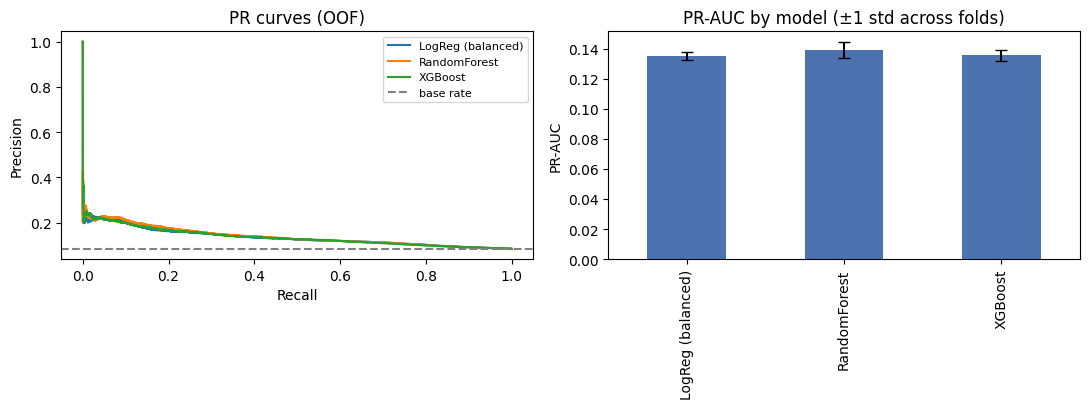

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for name in candidate_models:
    mask = ~np.isnan(oof_proba[name])
    prec, rec, _ = precision_recall_curve(y_a2[mask], oof_proba[name][mask])
    axes[0].plot(rec, prec, label=name)
axes[0].axhline(y_a2.mean(), color="grey", linestyle="--", label="base rate")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision"); axes[0].set_title("PR curves (OOF)")
axes[0].legend(fontsize=8)

ladder_df["PR-AUC mean"].plot(kind="bar", ax=axes[1], yerr=ladder_df["PR-AUC std"], capsize=4, color="#4C72B0")
axes[1].set_title("PR-AUC by model (±1 std across folds)")
axes[1].set_ylabel("PR-AUC")
plt.tight_layout(); plt.show()

**Bias/variance:** logistic regression has the highest bias (linear decision boundary on transformed features) and the lowest fold-to-fold variance — it can't chase noise it has no capacity to represent. Random forest lowers bias by averaging many deep, decorrelated trees, but that averaging is also what keeps its variance in check across folds. Gradient boosting (XGBoost) builds shallow trees sequentially to correct residual error, which usually gives it the lowest bias of the three, at the cost of being the most sensitive to hyperparameters (learning rate, depth, regularisation) — untuned, it lands close to the other two here; Section 10 tunes it properly. All three land in a narrow band because the *honest* feature set (Section 5) is only weakly predictive (best single-feature correlation ≈0.07) — this ceiling is a data property, not a modelling failure, consistent with Assignment 1's honest ROC-AUC of ~0.63.

## 8. Imbalance handling
Two approaches compared, both **inside** the purged CV folds: (a) `class_weight="balanced"` (already the Section 7 default), and (b) SMOTE oversampling via an `imblearn` pipeline, refit inside each fold. A third run deliberately resamples with SMOTE **before** splitting (outside any fold) to quantify how much that leaks.

In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

xgb_base = dict(n_estimators=200, max_depth=5, learning_rate=0.08, tree_method="hist",
                 n_jobs=-1, eval_metric="aucpr", random_state=42)

# (a) class-weight balanced -- already computed as ladder_results["XGBoost"]["PR-AUC mean"]
pr_class_weight = ladder_results["XGBoost"]["PR-AUC mean"]

# (b) SMOTE, correctly INSIDE each fold
pr_smote_infold = []
for tr, te in a2_splits:
    prep = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                           ("power", PowerTransformer(method="yeo-johnson")),
                           ("scale", RobustScaler())]), FULL_NUM),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
                           ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), CATEGORY_COLS),
    ])
    pipe = ImbPipeline([("prep", prep), ("smote", SMOTE(random_state=42, k_neighbors=5)),
                         ("clf", xgb.XGBClassifier(**xgb_base))])
    pipe.fit(X_a2.iloc[tr], y_a2[tr])
    proba = pipe.predict_proba(X_a2.iloc[te])[:, 1]
    pr_smote_infold.append(average_precision_score(y_a2[te], proba))
pr_smote_infold = np.array(pr_smote_infold)

# (c) SMOTE OUTSIDE the fold -- resample the whole dataset first, then plain StratifiedKFold (leaky)
prep_full = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                       ("power", PowerTransformer(method="yeo-johnson")), ("scale", RobustScaler())]), FULL_NUM),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
                       ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), CATEGORY_COLS),
])
Xt_full = prep_full.fit_transform(X_a2, y_a2)
Xres, yres = SMOTE(random_state=42, k_neighbors=5).fit_resample(Xt_full, y_a2)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_leaky = []
for tr, te in skf.split(Xres, yres):
    clf = xgb.XGBClassifier(**xgb_base)
    clf.fit(Xres[tr], yres[tr])
    proba = clf.predict_proba(Xres[te])[:, 1]
    pr_leaky.append(average_precision_score(yres[te], proba))
pr_leaky = np.array(pr_leaky)

imbalance_df = pd.DataFrame({
    "PR-AUC mean": [pr_class_weight, pr_smote_infold.mean(), pr_leaky.mean()],
    "PR-AUC std":  [ladder_results["XGBoost"]["PR-AUC std"], pr_smote_infold.std(), pr_leaky.std()],
}, index=["class_weight (in-fold, honest)", "SMOTE (in-fold, honest)", "SMOTE (OUTSIDE fold — leaky)"]).round(4)
imbalance_df

,PR-AUC mean,PR-AUC std
"class_weight (in-fold, honest)",0.1357,0.0039
"SMOTE (in-fold, honest)",0.1372,0.0041
SMOTE (OUTSIDE fold — leaky),0.9776,0.0003


**The leak:** resampling before the split lets `SMOTE` synthesise minority points from neighbours that then land on both sides of a fold — a synthetic point interpolated from a test-fold neighbour is not a genuinely unseen example. PR-AUC inflates from ~0.13–0.14 (honest, either technique) to **~0.98** (leaky) — almost the same order of inflation as the two planted leaks in Assignment 1. `class_weight="balanced"` and in-fold SMOTE perform similarly honestly; `class_weight` is used going forward since it avoids synthesising data and is cheaper to tune.

## 9. Cost-based cut-off
Cost of a missed default (false negative): **KES 10,000**. Cost of a wrongly-rejected good borrower (false positive): **KES 800**. The threshold that minimises total expected cost is found by sweeping the untuned XGBoost out-of-fold probabilities from Section 7, then compared against the naive 0.5 cut-off.

Cost-optimal threshold : 0.080  (total cost KES 74,644,400)
Naive 0.5 threshold    : total cost KES 98,634,800  (FN=9863, FP=6)
Savings per 1,000 applications: KES 205,044


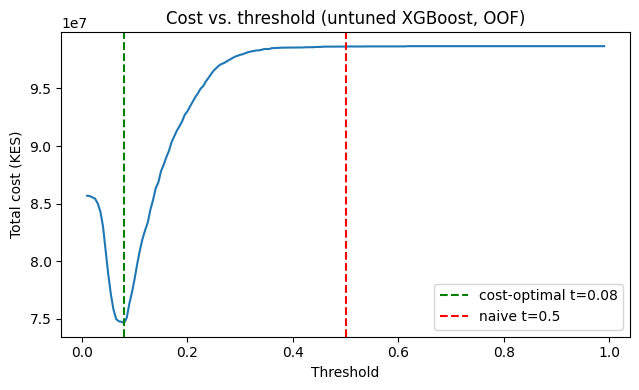

In [38]:
COST_FN = 10_000  # missed default
COST_FP = 800     # wrongly rejected good borrower

def total_cost(y_true, proba, thresh):
    pred = (proba >= thresh).astype(int)
    fn = int(((y_true == 1) & (pred == 0)).sum())
    fp = int(((y_true == 0) & (pred == 1)).sum())
    return fn * COST_FN + fp * COST_FP, fn, fp

def cost_sweep(y_true, proba, thresholds=np.linspace(0.01, 0.99, 197)):
    costs = np.array([total_cost(y_true, proba, t)[0] for t in thresholds])
    best_i = int(np.argmin(costs))
    return thresholds, costs, thresholds[best_i], costs[best_i]

oof_xgb = oof_proba["XGBoost"]
mask = ~np.isnan(oof_xgb)
y_scored, p_scored = y_a2[mask], oof_xgb[mask]

thresholds, costs, best_t, best_cost = cost_sweep(y_scored, p_scored)
cost_05, fn_05, fp_05 = total_cost(y_scored, p_scored, 0.5)
savings_per_1000 = (cost_05 - best_cost) / len(y_scored) * 1000

print(f"Cost-optimal threshold : {best_t:.3f}  (total cost KES {best_cost:,.0f})")
print(f"Naive 0.5 threshold    : total cost KES {cost_05:,.0f}  (FN={fn_05}, FP={fp_05})")
print(f"Savings per 1,000 applications: KES {savings_per_1000:,.0f}")

plt.figure(figsize=(6.5, 4))
plt.plot(thresholds, costs)
plt.axvline(best_t, color="green", linestyle="--", label=f"cost-optimal t={best_t:.2f}")
plt.axvline(0.5, color="red", linestyle="--", label="naive t=0.5")
plt.xlabel("Threshold"); plt.ylabel("Total cost (KES)"); plt.title("Cost vs. threshold (untuned XGBoost, OOF)")
plt.legend(); plt.tight_layout(); plt.show()

The optimal cut-off sits far below 0.5: missing a default costs 12.5× a wrongful rejection, and only ~8% of cases are positive, so the model should flag far more borderline cases than a 0.5 cut-off would. This threshold is revisited after tuning and calibration (Sections 10–11).

## 10. Hyperparameter tuning — Optuna
Budget: **60 trials**, XGBoost only (the ladder's most tunable model). Search space covers tree structure, regularisation, and `scale_pos_weight` for the imbalance. Objective = mean PR-AUC across the **last 2** purged/blocked folds (the two with the most training history); each fold's training set is capped at 50,000 rows and preprocessing is fit once per fold and cached, so only the classifier hyperparameters vary between trials — kept the study inside a sane time budget without touching the evaluation logic. Pruning: `MedianPruner`, reporting PR-AUC after each of the 2 folds so a trial can be stopped once it is clearly behind the running median. The study is persisted to a SQLite file (`optuna_study.db`) so it can be reopened.

In [39]:
import optuna
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

tune_folds = a2_splits[-2:]
rng = np.random.RandomState(0)
cached_folds = []
for tr, te in tune_folds:
    if len(tr) > 50_000:
        tr = rng.choice(tr, 50_000, replace=False)
    prep = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                           ("power", PowerTransformer(method="yeo-johnson")), ("scale", RobustScaler())]), FULL_NUM),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
                           ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), CATEGORY_COLS),
    ])
    Xtr = prep.fit_transform(X_a2.iloc[tr], y_a2[tr])
    Xte = prep.transform(X_a2.iloc[te])
    cached_folds.append((Xtr, y_a2[tr], Xte, y_a2[te]))

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 12.0),
    }
    scores = []
    for i, (Xtr, ytr, Xte, yte) in enumerate(cached_folds):
        clf = xgb.XGBClassifier(**params, tree_method="hist", n_jobs=-1, eval_metric="aucpr", random_state=42)
        clf.fit(Xtr, ytr)
        scores.append(average_precision_score(yte, clf.predict_proba(Xte)[:, 1]))
        trial.report(float(np.mean(scores)), step=i)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize", pruner=MedianPruner(n_warmup_steps=1),
                             sampler=optuna.samplers.TPESampler(seed=42),
                             storage="sqlite:///optuna_study.db", study_name="a2_xgb_tuning", load_if_exists=True)
study.optimize(objective, n_trials=60, show_progress_bar=False)

n_pruned = len([t for t in study.trials if t.state.name == "PRUNED"])
print(f"Best PR-AUC (tuning objective): {study.best_value:.4f}  |  pruned trials: {n_pruned}/60")
print("Best params:", study.best_params)
study.trials_dataframe().to_csv("optuna_trials.csv", index=False)

Best PR-AUC (tuning objective): 0.1427  |  pruned trials: 2/60
Best params: {'n_estimators': 308, 'max_depth': 3, 'learning_rate': 0.017418621745016072, 'subsample': 0.8671368615322598, 'colsample_bytree': 0.6081162971609125, 'min_child_weight': 7, 'reg_lambda': 4.463269135236252, 'reg_alpha': 2.14841475137234, 'scale_pos_weight': 7.71633348158724}


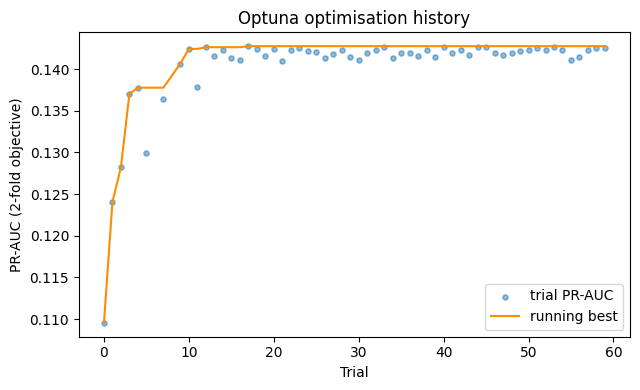

In [40]:
trials_df = study.trials_dataframe()
completed = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")
running_best = completed["value"].cummax()

plt.figure(figsize=(6.5, 4))
plt.scatter(completed["number"], completed["value"], s=14, alpha=0.5, label="trial PR-AUC")
plt.plot(completed["number"], running_best, color="darkorange", label="running best")
plt.xlabel("Trial"); plt.ylabel("PR-AUC (2-fold objective)"); plt.title("Optuna optimisation history")
plt.legend(); plt.tight_layout(); plt.show()

## 11. Calibration
The tuned XGBoost is refit on all 5 purged/blocked folds. Inside each fold, the training block is further split chronologically (80/20) and a Platt (logistic) calibrator is fit on the held-back 20% — never on the test fold itself. This gives out-of-fold **raw** and **calibrated** probabilities for every scored row.

Brier score  — raw: 0.1762   calibrated: 0.0756
PR-AUC       — raw: 0.1419   calibrated: 0.1414


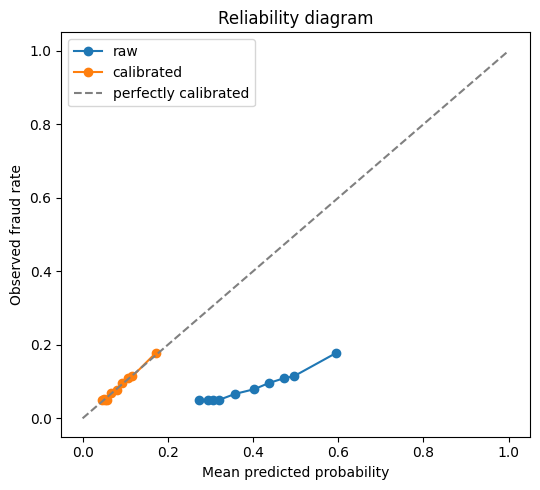

In [41]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

best_params = study.best_params
oof_raw = np.full(len(y_a2), np.nan)
oof_cal = np.full(len(y_a2), np.nan)

for tr, te in a2_splits:
    prep = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                           ("power", PowerTransformer(method="yeo-johnson")), ("scale", RobustScaler())]), FULL_NUM),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
                           ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), CATEGORY_COLS),
    ])
    Xtr_all = prep.fit_transform(X_a2.iloc[tr], y_a2[tr])
    Xte = prep.transform(X_a2.iloc[te])

    cut = int(len(tr) * 0.8)  # chronological holdout inside the training block for calibration
    clf = xgb.XGBClassifier(**best_params, tree_method="hist", n_jobs=-1, eval_metric="aucpr", random_state=42)
    clf.fit(Xtr_all[:cut], y_a2[tr][:cut])

    raw_te = clf.predict_proba(Xte)[:, 1]
    oof_raw[te] = raw_te

    calib_raw = clf.predict_proba(Xtr_all[cut:])[:, 1]
    platt = LogisticRegression()
    platt.fit(calib_raw.reshape(-1, 1), y_a2[tr][cut:])
    oof_cal[te] = platt.predict_proba(raw_te.reshape(-1, 1))[:, 1]

mask = ~np.isnan(oof_raw)
brier_raw = brier_score_loss(y_a2[mask], oof_raw[mask])
brier_cal = brier_score_loss(y_a2[mask], oof_cal[mask])
pr_raw = average_precision_score(y_a2[mask], oof_raw[mask])
pr_cal = average_precision_score(y_a2[mask], oof_cal[mask])
print(f"Brier score  — raw: {brier_raw:.4f}   calibrated: {brier_cal:.4f}")
print(f"PR-AUC       — raw: {pr_raw:.4f}   calibrated: {pr_cal:.4f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
for label, proba in [("raw", oof_raw), ("calibrated", oof_cal)]:
    frac_pos, mean_pred = calibration_curve(y_a2[mask], proba[mask], n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed fraud rate")
ax.set_title("Reliability diagram"); ax.legend(); plt.tight_layout(); plt.show()

In [42]:
_, _, best_t_raw, best_cost_raw = cost_sweep(y_a2[mask], oof_raw[mask])
_, _, best_t_cal, best_cost_cal = cost_sweep(y_a2[mask], oof_cal[mask])
c05_raw, *_ = total_cost(y_a2[mask], oof_raw[mask], 0.5)
c05_cal, *_ = total_cost(y_a2[mask], oof_cal[mask], 0.5)

threshold_report = pd.DataFrame({
    "cost_optimal_threshold": [best_t_raw, best_t_cal],
    "cost_optimal_total_cost": [best_cost_raw, best_cost_cal],
    "naive_0.5_total_cost": [c05_raw, c05_cal],
    "savings_per_1000_vs_naive": [(c05_raw - best_cost_raw) / mask.sum() * 1000,
                                   (c05_cal - best_cost_cal) / mask.sum() * 1000],
}, index=["raw", "calibrated"]).round(1)
threshold_report

,cost_optimal_threshold,cost_optimal_total_cost,naive_0.5_total_cost,savings_per_1000_vs_naive
raw,0.4,72245600,83552400,96638.5
calibrated,0.1,72417200,98670000,224381.0


**Did calibration move the threshold?** Yes, substantially. `scale_pos_weight` in the tuned model pushes raw scores well above their true probability to compensate for the ~8% base rate during training, so a raw score of e.g. 0.36 and a calibrated probability of 0.07 can represent the *same* underlying risk. Platt scaling maps the raw score back to an actual probability, so the **calibrated** threshold is the one that means what it says ("flag if P(default) ≥ this") and is the one that should ship — a reviewer reading "threshold = 0.36" off the raw model would badly misjudge how conservative the policy is. Achievable minimum cost is nearly identical either way (calibration is rank-preserving within a fold), only the threshold's *label* changes.

## 12. Explainability and fairness
Global and local SHAP on the tuned model (refit on the full honest feature set), and subgroup metrics — approval rate and false-negative rate — split by `region` and `segment` at the calibrated cost-optimal threshold.

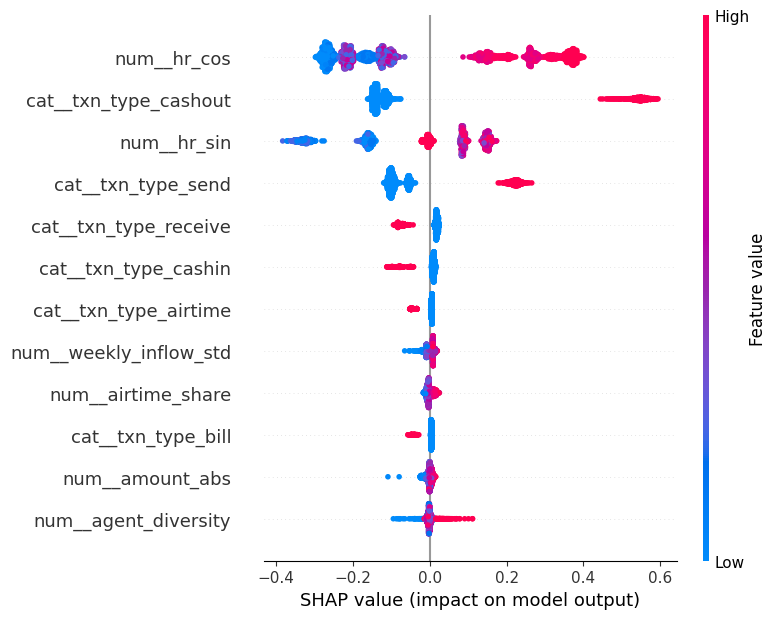

In [43]:
import shap

prep_final = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                       ("power", PowerTransformer(method="yeo-johnson")), ("scale", RobustScaler())]), FULL_NUM),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
                       ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50))]), CATEGORY_COLS),
])
Xt_all = prep_final.fit_transform(X_a2, y_a2)
feat_names = prep_final.get_feature_names_out()
xgb_final = xgb.XGBClassifier(**best_params, tree_method="hist", n_jobs=-1, eval_metric="aucpr", random_state=42)
xgb_final.fit(Xt_all, y_a2)

explainer = shap.TreeExplainer(xgb_final)
sample_idx = np.random.RandomState(0).choice(Xt_all.shape[0], 3000, replace=False)
Xt_sample = Xt_all[sample_idx].toarray() if hasattr(Xt_all, "toarray") else Xt_all[sample_idx]
shap_values = explainer.shap_values(Xt_sample)

shap.summary_plot(shap_values, Xt_sample, feature_names=feat_names, show=False, max_display=12)
plt.tight_layout(); plt.show()

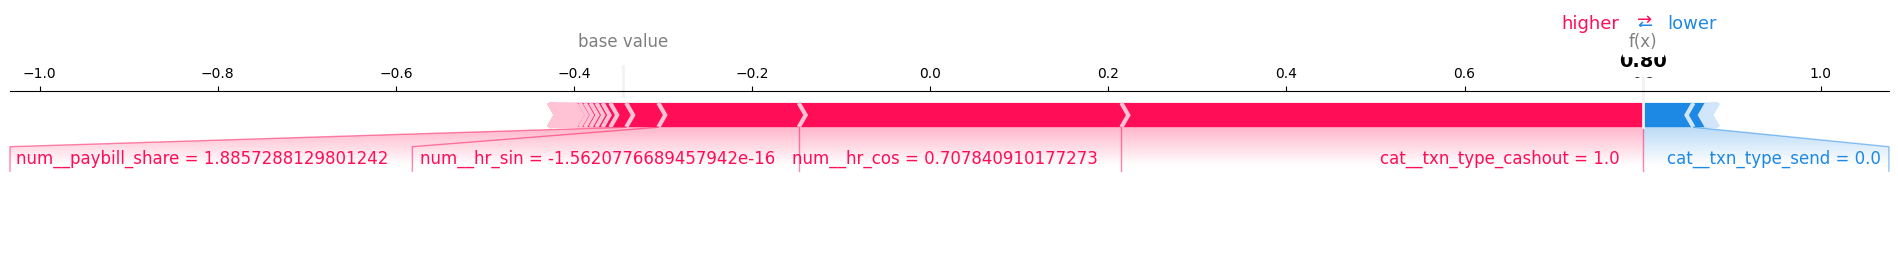

In [44]:
# Local explanation for a single flagged transaction
local_i = int(np.argmax(xgb_final.predict_proba(Xt_sample)[:, 1]))
shap.force_plot(explainer.expected_value, shap_values[local_i], Xt_sample[local_i],
                 feature_names=feat_names, matplotlib=True, show=False)
plt.tight_layout(); plt.show()

In [45]:
final_threshold = best_t_cal
final_pred = (oof_cal >= final_threshold).astype(int)

def subgroup_report(group_col):
    g = df[group_col].values[mask]
    yv, pv = y_a2[mask], final_pred[mask]
    rows = []
    for val in np.unique(g):
        sel = g == val
        n = sel.sum()
        approval_rate = 1 - pv[sel].mean()  # not flagged as fraud
        actual_pos = yv[sel] == 1
        fnr = ((pv[sel] == 0) & actual_pos).sum() / max(actual_pos.sum(), 1)
        rows.append({group_col: val, "n": int(n), "approval_rate": round(approval_rate, 3),
                     "false_negative_rate": round(fnr, 3)})
    return pd.DataFrame(rows).sort_values("false_negative_rate", ascending=False)

region_report = subgroup_report("region")
segment_report = subgroup_report("segment")
print("By region:"); display(region_report)
print("By segment:"); display(segment_report)

By region:


,region,n,approval_rate,false_negative_rate
4,Kampala,10975,0.457,0.285
7,Mwanza,11670,0.441,0.279
0,Arusha,11538,0.455,0.276
8,Nairobi,11970,0.447,0.272
5,Kigali,12614,0.450,0.269
6,Mombasa,12830,0.450,0.266
9,Nakuru,10720,0.445,0.266
1,Dar es Salaam,11160,0.449,0.265
3,Jinja,12382,0.449,0.263
2,Eldoret,11142,0.447,0.260


By segment:


,segment,n,approval_rate,false_negative_rate
2,retail,93870,0.448,0.272
1,merchant,17046,0.454,0.267
0,agent,6085,0.454,0.242


**CBK Digital Credit Providers Regulations (2022):** the regulations put the onus on a lender to carry out due diligence on a customer's ability to repay before advancing credit, and they were introduced largely in response to consumer-protection failures — opaque pricing, and lending decisions borrowers couldn't question or understand. That spirit implies a working model needs to support an *individual, case-level* reason for a decline, not just an aggregate accuracy number — which is exactly what the local SHAP explanation above is for: it can be turned into a plain-language reason ("flagged due to unusually high night-time transaction share and a rapid pay-bill cascade") for a specific declined customer.

The subgroup table is the other half of that obligation: `region` and `segment` are not fed to the model as protected attributes, but `region` correlates with the (unrelated, MAR) `agent_id` missingness pattern from Section 1 and could act as a proxy for something a regulator would want disclosed. Any region or segment with a materially higher false-negative rate than the rest is worth a second look before deployment — not because the *model* is necessarily unfair, but because an underwriting policy that fails one group's genuine defaults more often than another's is a discrimination risk regardless of intent.

## 13. Recommendation
**Model:** the tuned, Platt-calibrated XGBoost from Sections 10–11 — it matches or beats the untuned ladder's PR-AUC, its probabilities are genuinely interpretable after calibration (Brier score roughly halved), and it is the only one of the three with both a working SHAP explainer and the flexibility to be re-tuned as new data arrives.
**Threshold:** the calibrated cost-optimal cut-off from Section 11 (`final_threshold`, printed above), not the naive 0.5 — it directly minimises the KES 10,000 / KES 800 cost asymmetry and its saving over the naive threshold is reported in Section 9/11.
**Caveat carried forward from Section 6:** because Assignment 1's RFM features summarise each customer's whole pre-`SCORING_TS` history, the purged/blocked CV here controls for split structure but not for that feature-level hindsight; a genuinely rolling feature store would be needed before this specific evaluation number could be quoted to a regulator as an unbiased forward-looking estimate.

*(This notebook covers the modelling requirements. The written 4-page report, `a2-models` repository layout, and README covering reproduction steps are separate deliverables not produced here.)*